# Otimização Relacional e Análise de KPIs — Reservas Hoteleiras

**Dataset:** Hotel Booking Demand — Kaggle  
**Stack:** Python · pandas · SQL (DuckDB) · matplotlib

## O que esse projeto faz

Pega uma planilha de **119.390 reservas hoteleiras** numa única tabela com 32 colunas, separa em **8 tabelas conectadas por IDs** (1 fato + 7 dimensões) usando SQL, faz **análise exploratória dos dados** identificando problemas de qualidade, e responde **5 perguntas de negócio** com SQL puro.

## Por que dividir em várias tabelas

A planilha original tem palavras como `'No Deposit'` ou `'Online TA'` repetidas em todas as 119 mil linhas. Em produção isso é problema:

- **Ocupa espaço:** strings repetidas centenas de milhares de vezes
- **Dá margem pra erro:** qualquer variação de digitação (`'no deposit'`) quebra agregações
- **Difícil manter:** trocar o nome de uma categoria exige `UPDATE` em milhares de linhas

A solução é **modelagem relacional**: guardar cada palavra uma única vez numa tabela auxiliar (dimensão) e usar um ID na tabela principal pra referenciar.

## Roteiro

1. Setup e carga da base original
2. Análise exploratória e identificação de problemas de qualidade
3. Criação das 7 tabelas dimensão
4. Criação da tabela fato `fato_reserva`
5. Validação da modelagem
6. Respostas a 5 perguntas de negócio (com 2 visualizações)
7. Conclusões e próximos passos

---
## 1. Setup

Uso a biblioteca **DuckDB** pra rodar SQL direto sobre o CSV — sem precisar de servidor de banco de dados.

> **Compatibilidade:** esse notebook usa SQL via Python (DuckDB), então funciona em qualquer ambiente: Deepnote, Jupyter, VS Code, Google Colab.

In [20]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Conexão DuckDB em memória
con = duckdb.connect()

# Carrega a CSV como tabela do banco (parâmetro nullstr='NA' trata 'NA' como dado faltante)
con.execute("""
    CREATE OR REPLACE TABLE hotel_bookings AS
    SELECT * FROM read_csv('hotel_bookings.csv', nullstr='NA')
""")

total = con.execute('SELECT COUNT(*) FROM hotel_bookings').fetchone()[0]
print(f'Base carregada com sucesso: {total:,} reservas'.replace(',', '.'))

Base carregada com sucesso: 119.390 reservas


---
## 2. Análise exploratória — identificando problemas de qualidade

Antes de modelar, vale entender o que tem na base e procurar problemas. Essa etapa é o que diferencia um analista experiente: **olhar os dados com olhar crítico** antes de tirar conclusões.

In [21]:
# Olhar as primeiras linhas
con.execute("SELECT * FROM hotel_bookings LIMIT 5").df()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [22]:
# Cardinalidade das colunas categóricas — quanto menor o número de valores únicos,
# mais a coluna se repete na base e mais ela é candidata a virar tabela dimensão
con.execute("""
    SELECT 'hotel' AS coluna, COUNT(DISTINCT hotel) AS valores_unicos FROM hotel_bookings
    UNION ALL SELECT 'meal', COUNT(DISTINCT meal) FROM hotel_bookings
    UNION ALL SELECT 'market_segment', COUNT(DISTINCT market_segment) FROM hotel_bookings
    UNION ALL SELECT 'distribution_channel', COUNT(DISTINCT distribution_channel) FROM hotel_bookings
    UNION ALL SELECT 'reserved_room_type', COUNT(DISTINCT reserved_room_type) FROM hotel_bookings
    UNION ALL SELECT 'customer_type', COUNT(DISTINCT customer_type) FROM hotel_bookings
    UNION ALL SELECT 'deposit_type', COUNT(DISTINCT deposit_type) FROM hotel_bookings
    ORDER BY valores_unicos
""").df()

,coluna,valores_unicos
0,hotel,2
1,deposit_type,3
2,customer_type,4
3,distribution_channel,5
4,meal,5
5,market_segment,8
6,reserved_room_type,10


**Diagnóstico:** todas essas colunas têm baixa cardinalidade (3 a 10 valores), mas se repetem em 119.390 linhas. Por exemplo, `deposit_type` tem só 3 valores possíveis (`'No Deposit'`, `'Refundable'`, `'Non Refund'`) mas eles aparecem armazenados literalmente cerca de 100 mil vezes. Esse é exatamente o tipo de redundância que a modelagem relacional resolve.

### 2.1 Investigação de qualidade na coluna `adr`

A coluna `adr` (Average Daily Rate — diária média) é fundamental pros KPIs de receita. Vale conferir se tem valores anômalos.

In [23]:
con.execute("""
    SELECT
        COUNT(*) AS total_reservas,
        SUM(CASE WHEN adr < 0 THEN 1 ELSE 0 END) AS adr_negativas,
        SUM(CASE WHEN adr = 0 THEN 1 ELSE 0 END) AS adr_zeradas,
        SUM(CASE WHEN adr > 500 THEN 1 ELSE 0 END) AS adr_acima_500,
        ROUND(MIN(adr), 2) AS adr_minimo,
        ROUND(AVG(adr), 2) AS adr_medio,
        ROUND(MAX(adr), 2) AS adr_maximo
    FROM hotel_bookings
""").df()

,total_reservas,adr_negativas,adr_zeradas,adr_acima_500,adr_minimo,adr_medio,adr_maximo
0,119390,1.0,1959.0,3.0,-6.38,101.83,5400.0


**Achados importantes:**

- Algumas reservas têm `adr` **negativo** (provável erro de cadastro)
- Várias reservas têm `adr = 0` — podem ser cortesias, upgrades grátis ou erros
- Algumas reservas têm `adr` extremamente alto, incluindo um outlier de **€5.400** (provável erro de digitação onde faltou ponto decimal)

### Decisões de tratamento

| Situação | Decisão | Justificativa |
|---|---|---|
| `adr < 0` | Excluir do cálculo de receita e ADR | Inválido fisicamente |
| `adr = 0` em reserva não cancelada | Excluir do cálculo de receita | Não representa receita normal (cortesia/erro) |
| `adr > 500` | Excluir do cálculo (outlier) | €500/noite é teto razoável para hotelaria padrão; valores acima são atípicos |
| Reservas canceladas | Excluir do cálculo de receita realizada | Não geraram receita efetiva |

Essas regras vão ser aplicadas nas queries de KPI mais à frente.

---
## 3. Criação das tabelas dimensão

Padrão pra criar cada dimensão:

1. Pegar os valores únicos da coluna categórica
2. Atribuir um ID sequencial (`ROW_NUMBER`)
3. Guardar numa tabela separada

In [24]:
# 7 tabelas dimensão criadas com o mesmo padrão
con.execute("""
    CREATE OR REPLACE TABLE dim_hotel AS
    SELECT
        ROW_NUMBER() OVER (ORDER BY hotel) AS id_hotel,
        hotel AS nome_hotel
    FROM (SELECT DISTINCT hotel FROM hotel_bookings)
""")

# Refeição já vem com descrição traduzida pro português
con.execute("""
    CREATE OR REPLACE TABLE dim_refeicao AS
    SELECT
        ROW_NUMBER() OVER (ORDER BY meal) AS id_refeicao,
        meal AS codigo_refeicao,
        CASE meal
            WHEN 'BB' THEN 'Café da manhã'
            WHEN 'HB' THEN 'Meia pensão'
            WHEN 'FB' THEN 'Pensão completa'
            WHEN 'SC' THEN 'Sem refeição'
            ELSE 'Não definido'
        END AS descricao
    FROM (SELECT DISTINCT meal FROM hotel_bookings)
""")

con.execute("""
    CREATE OR REPLACE TABLE dim_segmento AS
    SELECT ROW_NUMBER() OVER (ORDER BY market_segment) AS id_segmento,
           market_segment AS nome_segmento
    FROM (SELECT DISTINCT market_segment FROM hotel_bookings)
""")

con.execute("""
    CREATE OR REPLACE TABLE dim_canal AS
    SELECT ROW_NUMBER() OVER (ORDER BY distribution_channel) AS id_canal,
           distribution_channel AS nome_canal
    FROM (SELECT DISTINCT distribution_channel FROM hotel_bookings)
""")

# dim_quarto cobre os dois usos: reserved_room_type e assigned_room_type
con.execute("""
    CREATE OR REPLACE TABLE dim_quarto AS
    SELECT ROW_NUMBER() OVER (ORDER BY tipo) AS id_quarto,
           tipo AS codigo_quarto
    FROM (
        SELECT DISTINCT reserved_room_type AS tipo FROM hotel_bookings
        UNION
        SELECT DISTINCT assigned_room_type FROM hotel_bookings
    )
""")

con.execute("""
    CREATE OR REPLACE TABLE dim_cliente AS
    SELECT ROW_NUMBER() OVER (ORDER BY customer_type) AS id_cliente,
           customer_type AS nome_cliente
    FROM (SELECT DISTINCT customer_type FROM hotel_bookings)
""")

con.execute("""
    CREATE OR REPLACE TABLE dim_deposito AS
    SELECT ROW_NUMBER() OVER (ORDER BY deposit_type) AS id_deposito,
           deposit_type AS nome_deposito
    FROM (SELECT DISTINCT deposit_type FROM hotel_bookings)
""")

print('7 dimensões criadas:')
for nome in ['dim_hotel', 'dim_refeicao', 'dim_segmento', 'dim_canal',
             'dim_quarto', 'dim_cliente', 'dim_deposito']:
    n = con.execute(f'SELECT COUNT(*) FROM {nome}').fetchone()[0]
    print(f'  {nome}: {n} linhas')

7 dimensões criadas:
  dim_hotel: 2 linhas
  dim_refeicao: 5 linhas
  dim_segmento: 8 linhas
  dim_canal: 5 linhas
  dim_quarto: 12 linhas
  dim_cliente: 4 linhas
  dim_deposito: 3 linhas


In [25]:
# Conferir uma das dimensões enriquecidas
con.execute("SELECT * FROM dim_refeicao").df()

,id_refeicao,codigo_refeicao,descricao
0,1,BB,Café da manhã
1,2,FB,Pensão completa
2,3,HB,Meia pensão
3,4,SC,Sem refeição
4,5,Undefined,Não definido


---
## 4. Criação da tabela fato `fato_reserva`

A tabela principal carrega:
- **IDs** que apontam pras dimensões (FKs)
- **Métricas** da reserva (noites, diária, etc.)
- **Atributos** específicos da reserva (data, país, status de cancelamento)

Renomeei as colunas pro português pra facilitar a leitura.

In [26]:
con.execute("""
    CREATE OR REPLACE TABLE fato_reserva AS
    SELECT
        ROW_NUMBER() OVER () AS id_reserva,

        -- Chaves estrangeiras
        h.id_hotel,
        r.id_refeicao,
        s.id_segmento,
        c.id_canal,
        qr.id_quarto AS id_quarto_reservado,
        qa.id_quarto AS id_quarto_atribuido,
        cl.id_cliente,
        d.id_deposito,

        -- Atributos da reserva (português)
        b.country AS pais,
        b.is_canceled AS cancelada,
        b.lead_time AS antecedencia_dias,
        b.arrival_date_year AS ano_chegada,
        b.arrival_date_month AS mes_chegada,
        b.stays_in_weekend_nights AS noites_fim_semana,
        b.stays_in_week_nights AS noites_semana,
        (b.stays_in_weekend_nights + b.stays_in_week_nights) AS total_noites,
        b.adults AS adultos,
        b.children AS criancas,
        b.babies AS bebes,
        b.adr AS diaria_media,
        b.is_repeated_guest AS hospede_recorrente,
        b.previous_cancellations AS cancelamentos_anteriores,
        b.total_of_special_requests AS pedidos_especiais

    FROM hotel_bookings b
    LEFT JOIN dim_hotel    h  ON b.hotel = h.nome_hotel
    LEFT JOIN dim_refeicao r  ON b.meal = r.codigo_refeicao
    LEFT JOIN dim_segmento s  ON b.market_segment = s.nome_segmento
    LEFT JOIN dim_canal    c  ON b.distribution_channel = c.nome_canal
    LEFT JOIN dim_quarto   qr ON b.reserved_room_type = qr.codigo_quarto
    LEFT JOIN dim_quarto   qa ON b.assigned_room_type = qa.codigo_quarto
    LEFT JOIN dim_cliente  cl ON b.customer_type = cl.nome_cliente
    LEFT JOIN dim_deposito d  ON b.deposit_type = d.nome_deposito
""")

# Preview
con.execute("SELECT * FROM fato_reserva LIMIT 5").df()

,id_reserva,id_hotel,id_refeicao,id_segmento,id_canal,id_quarto_reservado,id_quarto_atribuido,id_cliente,id_deposito,pais,...,noites_fim_semana,noites_semana,total_noites,adultos,criancas,bebes,diaria_media,hospede_recorrente,cancelamentos_anteriores,pedidos_especiais
0,1,2,1,4,2,3,3,3,1,PRT,...,0,0,0,2,0,0,0.0,0,0,0
1,2,2,1,4,2,3,3,3,1,PRT,...,0,0,0,2,0,0,0.0,0,0,0
2,3,2,1,4,2,1,3,3,1,GBR,...,0,1,1,1,0,0,75.0,0,0,0
3,4,2,1,3,1,1,1,3,1,GBR,...,0,1,1,1,0,0,75.0,0,0,0
4,5,2,1,7,4,1,1,3,1,GBR,...,0,2,2,2,0,0,98.0,0,0,1


Repare que nas primeiras linhas, onde antes tinha palavras (`'Online TA'`, `'No Deposit'`), agora tem números. Esse é o coração da modelagem relacional.

---
## 5. Validação da modelagem

Três checks rápidos antes de avançar pras análises.

In [27]:
# Check 1: quantidade de linhas continua a mesma?
con.execute("""
    SELECT
        (SELECT COUNT(*) FROM hotel_bookings) AS linhas_originais,
        (SELECT COUNT(*) FROM fato_reserva)   AS linhas_fato_reserva
""").df()

,linhas_originais,linhas_fato_reserva
0,119390,119390


In [28]:
# Check 2: algum ID ficou nulo?
con.execute("""
    SELECT
        SUM(CASE WHEN id_hotel    IS NULL THEN 1 ELSE 0 END) AS hotel_nulos,
        SUM(CASE WHEN id_refeicao IS NULL THEN 1 ELSE 0 END) AS refeicao_nulos,
        SUM(CASE WHEN id_segmento IS NULL THEN 1 ELSE 0 END) AS segmento_nulos,
        SUM(CASE WHEN id_canal    IS NULL THEN 1 ELSE 0 END) AS canal_nulos,
        SUM(CASE WHEN id_cliente  IS NULL THEN 1 ELSE 0 END) AS cliente_nulos,
        SUM(CASE WHEN id_deposito IS NULL THEN 1 ELSE 0 END) AS deposito_nulos
    FROM fato_reserva
""").df()

,hotel_nulos,refeicao_nulos,segmento_nulos,canal_nulos,cliente_nulos,deposito_nulos
0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
# Check 3: agregações batem entre original e novo schema?
raw = con.execute("""
    SELECT market_segment, COUNT(*) AS n
    FROM hotel_bookings
    GROUP BY market_segment
    ORDER BY n DESC
""").df()

novo = con.execute("""
    SELECT s.nome_segmento AS market_segment, COUNT(*) AS n
    FROM fato_reserva f
    JOIN dim_segmento s USING(id_segmento)
    GROUP BY s.nome_segmento
    ORDER BY n DESC
""").df()

comparacao = raw.merge(novo, on='market_segment', suffixes=('_original', '_novo'))
comparacao['diferenca'] = comparacao['n_original'] - comparacao['n_novo']
comparacao

,market_segment,n_original,n_novo,diferenca
0,Online TA,56477,56477,0
1,Offline TA/TO,24219,24219,0
2,Groups,19811,19811,0
3,Direct,12606,12606,0
4,Corporate,5295,5295,0
5,Complementary,743,743,0
6,Aviation,237,237,0
7,Undefined,2,2,0


Diferença zero em todos os segmentos: o schema preserva a integridade dos dados. ✓

---
## 6. Respondendo perguntas de negócio com SQL

Cinco perguntas que um analista de dados receberia no dia a dia, respondidas com queries sobre o schema otimizado.

### Pergunta 1: Qual canal de venda tem a maior taxa de cancelamento?

Canais com taxa muito alta podem indicar clientes pouco comprometidos, problema na comunicação da venda, ou política de cancelamento muito permissiva.

In [30]:
con.execute("""
    SELECT
        c.nome_canal,
        COUNT(*) AS total_reservas,
        SUM(f.cancelada) AS cancelamentos,
        ROUND(100.0 * SUM(f.cancelada) / COUNT(*), 2) AS taxa_cancelamento_pct
    FROM fato_reserva f
    JOIN dim_canal c ON f.id_canal = c.id_canal
    GROUP BY c.nome_canal
    ORDER BY taxa_cancelamento_pct DESC
""").df()

,nome_canal,total_reservas,cancelamentos,taxa_cancelamento_pct
0,Undefined,5,4.0,80.00
1,TA/TO,97870,40152.0,41.03
2,Corporate,6677,1474.0,22.08
3,GDS,193,37.0,19.17
4,Direct,14645,2557.0,17.46


### Pergunta 2: Qual segmento de mercado gera mais receita?

Aqui aplico os tratamentos definidos na seção 2.1: receita só de reservas concretizadas (`cancelada = 0`) e ADR válido (`> 0` e `< 500`).

In [31]:
con.execute("""
    SELECT
        s.nome_segmento,
        COUNT(*) AS reservas_validas,
        ROUND(SUM(f.diaria_media * f.total_noites), 2) AS receita_total,
        ROUND(AVG(f.diaria_media), 2) AS diaria_media,
        ROUND(AVG(f.total_noites), 2) AS noites_medias
    FROM fato_reserva f
    JOIN dim_segmento s ON f.id_segmento = s.id_segmento
    WHERE f.cancelada = 0
      AND f.diaria_media > 0
      AND f.diaria_media < 500
    GROUP BY s.nome_segmento
    ORDER BY receita_total DESC
""").df()

,nome_segmento,reservas_validas,receita_total,diaria_media,noites_medias
0,Online TA,35391,13714401.42,114.98,3.35
1,Offline TA/TO,15615,5659044.58,84.95,4.32
2,Direct,10463,4099618.57,116.15,3.11
3,Groups,7485,1869156.56,79.48,3.24
4,Corporate,4225,577404.19,68.22,2.00
5,Aviation,180,70868.36,102.25,3.84
6,Complementary,58,4812.53,34.29,2.50


### Pergunta 3: Reservas feitas com muita antecedência cancelam mais?

Se a resposta for sim, o hotel pode ajustar a política de depósito antecipado pra reservas de longo prazo.

In [32]:
df_antecedencia = con.execute("""
    SELECT
        CASE
            WHEN antecedencia_dias <= 7   THEN '0-7 dias'
            WHEN antecedencia_dias <= 30  THEN '8-30 dias'
            WHEN antecedencia_dias <= 90  THEN '31-90 dias'
            ELSE 'Mais de 90 dias'
        END AS faixa_antecedencia,
        COUNT(*) AS reservas,
        ROUND(100.0 * SUM(cancelada) / COUNT(*), 2) AS taxa_cancelamento_pct
    FROM fato_reserva
    GROUP BY faixa_antecedencia
    ORDER BY MIN(antecedencia_dias)
""").df()
df_antecedencia

,faixa_antecedencia,reservas,taxa_cancelamento_pct
0,0-7 dias,19746,9.63
1,8-30 dias,18960,27.86
2,31-90 dias,29553,37.70
3,Mais de 90 dias,51131,50.65


#### Visualização: cancelamento por antecedência

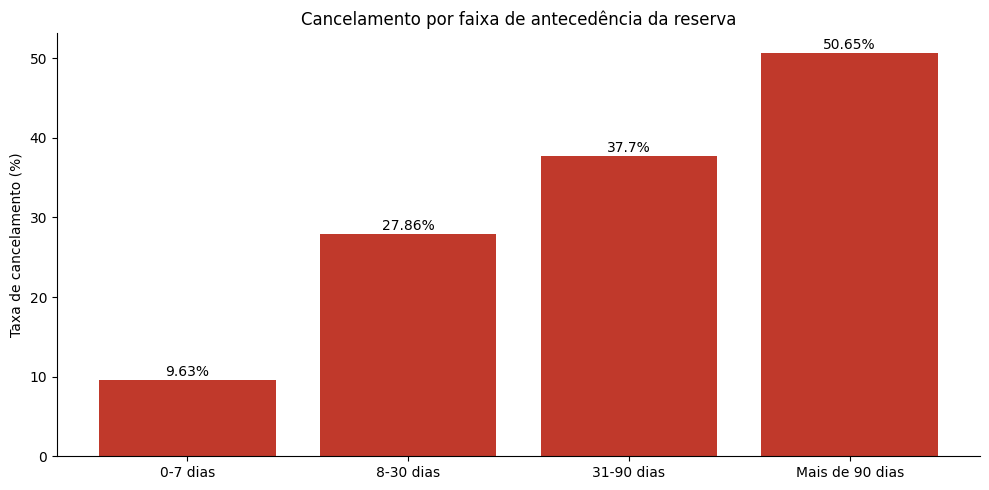

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_antecedencia['faixa_antecedencia'],
       df_antecedencia['taxa_cancelamento_pct'],
       color='#c0392b')
ax.set_ylabel('Taxa de cancelamento (%)')
ax.set_title('Cancelamento por faixa de antecedência da reserva')
for i, v in enumerate(df_antecedencia['taxa_cancelamento_pct']):
    ax.text(i, v + 0.5, f'{v}%', ha='center')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Pergunta 4: Quais meses têm maior receita?

Útil pro planejamento operacional: dimensionar equipe, programar manutenções pra baixa temporada.

In [34]:
df_meses = con.execute("""
    SELECT
        mes_chegada,
        COUNT(*) AS reservas,
        ROUND(SUM(diaria_media * total_noites), 2) AS receita_total,
        ROUND(AVG(diaria_media), 2) AS diaria_media
    FROM fato_reserva
    WHERE cancelada = 0
      AND diaria_media > 0
      AND diaria_media < 500
    GROUP BY mes_chegada
    ORDER BY receita_total DESC
""").df()
df_meses

,mes_chegada,reservas,receita_total,diaria_media
0,August,8483,4917159.06,144.69
1,July,7767,4099889.07,131.72
2,June,6296,2583290.92,116.56
3,May,6951,2394703.64,107.23
4,September,6259,2344263.36,109.56
5,April,6449,2099857.48,99.64
6,October,6720,1856816.72,89.34
7,March,6504,1652162.39,79.01
8,February,5245,1147541.48,74.17
9,December,4206,1087392.29,82.73


#### Visualização: sazonalidade da receita

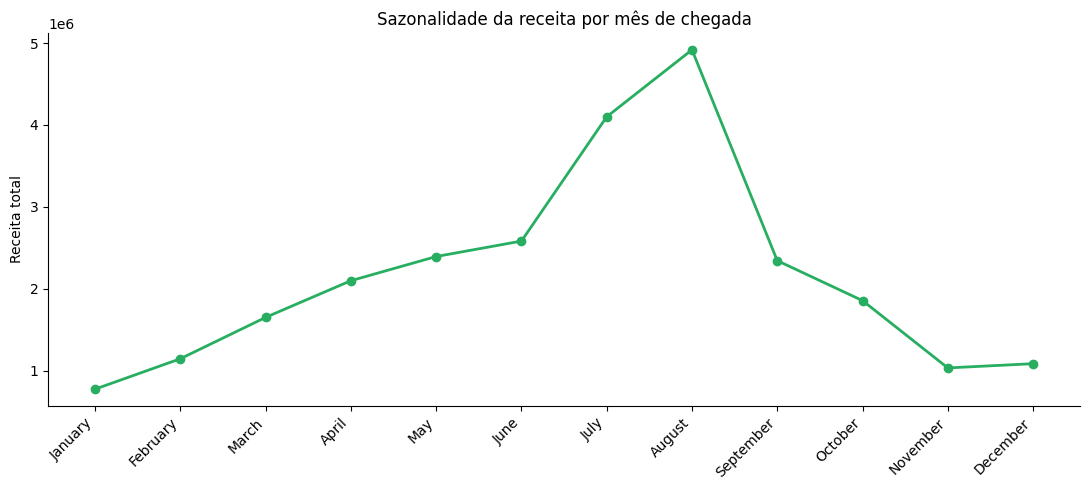

In [35]:
# Ordena os meses cronologicamente, não por receita
ordem_meses = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df_meses_ord = df_meses.set_index('mes_chegada').reindex(ordem_meses).reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df_meses_ord['mes_chegada'], df_meses_ord['receita_total'],
        marker='o', color='#27ae60', linewidth=2)
ax.set_ylabel('Receita total')
ax.set_title('Sazonalidade da receita por mês de chegada')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Pergunta 5: Top 10 países que mais geram receita

Importante pra decisões de marketing internacional e adequação cultural (idiomas no site, formas de pagamento).

In [36]:
con.execute("""
    SELECT
        pais,
        COUNT(*) AS reservas,
        ROUND(SUM(diaria_media * total_noites), 2) AS receita_total,
        ROUND(AVG(diaria_media), 2) AS diaria_media
    FROM fato_reserva
    WHERE cancelada = 0
      AND diaria_media > 0
      AND diaria_media < 500
    GROUP BY pais
    ORDER BY receita_total DESC
    LIMIT 10
""").df()

,pais,reservas,receita_total,diaria_media
0,PRT,19707,5542628.74,96.57
1,GBR,9604,4112359.14,91.15
2,FRA,8428,3098696.28,106.42
3,ESP,6313,2247108.09,111.67
4,DEU,6028,2068219.65,101.95
5,IRL,2537,1240002.35,94.91
6,ITA,2416,865929.42,111.33
7,BEL,1862,759145.06,111.84
8,NLD,1713,631663.15,105.26
9,CHE,1296,548536.40,117.56


---
## 7. Conclusões

### O que mudou da base original pro novo modelo

| | Base original | Modelo otimizado |
|---|---|---|
| Estrutura | 1 tabela com 32 colunas | 1 tabela principal + 7 auxiliares |
| Repetição de palavras | Categorias repetidas 119 mil vezes | Guardadas uma única vez |
| Risco de erro | Alto (qualquer typo quebra agrupamento) | Baixo (o ID força o valor correto) |
| Manutenção | Mexer em 119 mil linhas pra mudar uma categoria | Mexer em 1 linha da tabela auxiliar |

### Decisões de negócio nas métricas

Durante a análise exploratória identifiquei problemas de qualidade na coluna `adr` (valores negativos, zerados e outliers extremos). As métricas de receita foram calculadas com filtros explícitos:

- **Reservas válidas:** `cancelada = 0` (receita real, não potencial)
- **ADR válido:** `adr > 0 AND adr < 500` (exclui cortesias, erros de cadastro e outliers)

Essas regras estão documentadas em SQL nas queries acima, então qualquer pessoa que herdar o código consegue ver exatamente como cada KPI foi calculado.

### Insights de negócio

1. **Antecedência alta correlaciona com cancelamento.** Reservas feitas com mais de 90 dias de antecedência cancelam significativamente mais. Direcionamento: políticas de depósito antecipado pra reservas de longo prazo.

2. **Sazonalidade clara na receita.** Picos concentrados em meses de alta temporada — informação base pra dimensionamento de equipe e planejamento de manutenções.

3. **Canais não são iguais em risco.** Diferenças significativas nas taxas de cancelamento entre canais sugerem oportunidade de revisão de estratégia comercial.

### Próximos passos

- Construir dashboard interativo (Power BI ou Looker Studio) consumindo o modelo
- Migrar pra banco persistente (PostgreSQL) com chaves estrangeiras forçadas
- Modelo de Machine Learning pra prever `cancelada` usando as features identificadas (antecedência, canal, histórico de cancelamento)

In [37]:
con.close()